<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/8aprilConvNeXtBYOL_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny
from torch.utils.data import DataLoader, random_split
import torchvision.transforms.functional as TF

import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [11]:
# BYOL strong augmentation
byol_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Train/Val
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [12]:
class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        model = convnext_tiny(pretrained=True)
        self.features = model.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)  # [B,768]

In [13]:
class MLP(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, dim)
        )

    def forward(self, x):
        return self.net(x)


class BYOL(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = Backbone()
        self.projector = MLP()
        self.predictor = MLP()

    def forward(self, x):
        f = self.backbone(x)
        z = self.projector(f)
        p = self.predictor(z)
        return p

In [14]:
def byol_loss(p, z):
    z = z.detach()
    p = nn.functional.normalize(p, dim=-1)
    z = nn.functional.normalize(z, dim=-1)
    return 2 - 2 * (p * z).sum(dim=-1).mean()

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

student = BYOL().to(device)
teacher = copy.deepcopy(student).to(device)

for p in teacher.parameters():
    p.requires_grad = False

optimizer = optim.Adam(student.parameters(), lr=1e-4)

dataset = datasets.ImageFolder("/content/drive/MyDrive/ResearchData/April26/1AprilreshuffledDataset", transform=byol_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

momentum = 0.996

for epoch in range(5):
    for images, _ in loader:

        images = images.to(device)

        # two views
        x1 = images
        x2 = images.flip(-1)  # simple second view

        p1 = student(x1)
        with torch.no_grad():
            z2 = teacher(x2)

        loss = byol_loss(p1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # EMA update
        for ps, pt in zip(student.parameters(), teacher.parameters()):
            pt.data = momentum * pt.data + (1 - momentum) * ps.data

    print(f"BYOL Epoch {epoch} Loss: {loss.item():.4f}")

BYOL Epoch 0 Loss: 0.3878
BYOL Epoch 1 Loss: 0.3507
BYOL Epoch 2 Loss: 0.2776
BYOL Epoch 3 Loss: 0.2873
BYOL Epoch 4 Loss: 0.2676


In [16]:
full_dataset = datasets.ImageFolder("/content/drive/MyDrive/ResearchData/April26/1AprilreshuffledDataset", transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

In [17]:
class Classifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.fc(x)

In [18]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)

    mixed_x = lam*x + (1-lam)*x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred,y_a)+(1-lam)*criterion(pred,y_b)

In [19]:
model = Classifier(student.backbone, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            _, pred = torch.max(out, 1)
            correct += (pred==y).sum().item()
            total += y.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return correct/total, all_labels, all_preds

In [20]:
epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        x, y_a, y_b, lam = mixup_data(x, y)

        out = model(x)
        loss = mixup_loss(criterion, out, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, pred = torch.max(out,1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    train_acc = correct/total
    val_acc, y_true, y_pred = evaluate(model, val_loader)

    train_losses.append(total_loss)
    val_losses.append(0)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f}")

Epoch 1 Train Acc: 0.3579 Val Acc: 0.6250
Epoch 2 Train Acc: 0.4575 Val Acc: 0.6562
Epoch 3 Train Acc: 0.5123 Val Acc: 0.7009
Epoch 4 Train Acc: 0.5582 Val Acc: 0.6920
Epoch 5 Train Acc: 0.6051 Val Acc: 0.7411
Epoch 6 Train Acc: 0.7148 Val Acc: 0.7455
Epoch 7 Train Acc: 0.6655 Val Acc: 0.7188
Epoch 8 Train Acc: 0.5861 Val Acc: 0.7455
Epoch 9 Train Acc: 0.7069 Val Acc: 0.7455
Epoch 10 Train Acc: 0.5772 Val Acc: 0.7545
Epoch 11 Train Acc: 0.6141 Val Acc: 0.7500
Epoch 12 Train Acc: 0.6085 Val Acc: 0.7411
Epoch 13 Train Acc: 0.6745 Val Acc: 0.7366
Epoch 14 Train Acc: 0.6477 Val Acc: 0.7366
Epoch 15 Train Acc: 0.6387 Val Acc: 0.7366


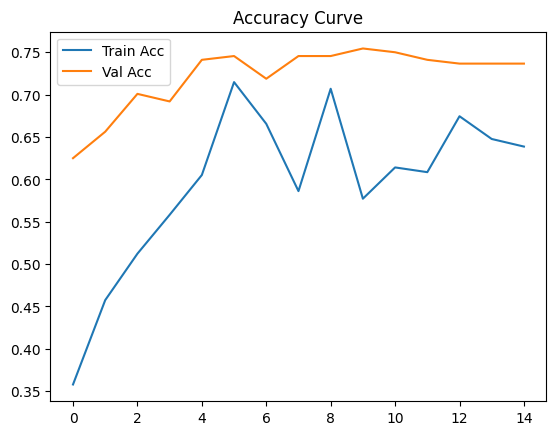

In [21]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

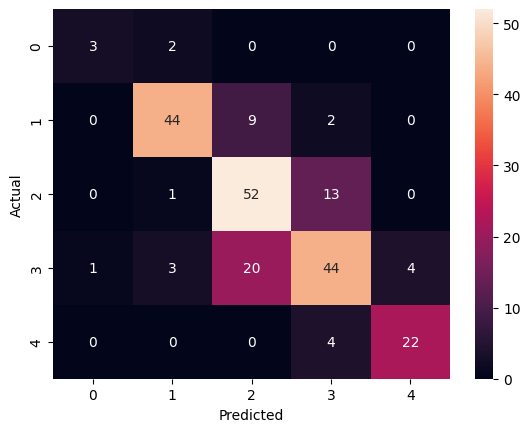

In [22]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()